In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import pygmt
from pygmt_helper import plotting
import oq_wrapper as oqw

import nn_gmm as nng
import ml_tools as mlt

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"


/Users/claudy/dev/work/code/seismic_hazard_analyis/seismic_hazard_analysis/site_source.py:928: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scenario_section_ids[i],
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Failed to import the streamlit module. This is likely because streamlit is not installed.


In [2]:
result_dir = Path("/Users/claudy/dev/work/data/nn_gmm/results/0616_1451_test_10Epochs_noLatLon")
empdb_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/20250616_CS200m_empdb.db")

In [3]:
run_config = nng.RunConfig.from_yaml(result_dir / "run_config.yaml")
val_pred_df = pd.read_parquet(result_dir / "val_results.parquet").sort_index()
metrics = pd.read_parquet(result_dir / "metrics.parquet")

In [4]:
with nng.IMDB(run_config.imdb_ffp, readonly=True) as imdb:
    val_sim_df = imdb.get_im_data_tmp_table(run_config.ims, val_pred_df.index.values.astype(int)).sort_index()

assert val_pred_df.index.equals(val_sim_df.index)

In [5]:
with nng.EmpiricalDB(empdb_ffp, readonly=True) as empdb:
    val_emp_df = empdb.get_gm_params_tmp_table(val_pred_df.index.values.astype(int))

assert val_emp_df.index.equals(val_pred_df.index)
assert val_emp_df.index.equals(val_sim_df.index)

In [6]:
res_df = pd.DataFrame(data=np.log(val_sim_df[run_config.ims].values) - val_pred_df[run_config.pred_mean_keys].values, index=val_pred_df.index, columns=run_config.ims)
emp_res_red = pd.DataFrame(data=np.log(val_sim_df[nng.constants.PSA_KEYS].values) - val_emp_df[nng.constants.GMM_PSA_MEAN_KEYS].values, index=val_emp_df.index, columns=nng.constants.PSA_KEYS)

## Metrics

In [7]:
metrics

,loss_hist_train,loss_hist_val,mse_hist_train,mse_hist_val,mean_sigma_hist_train,mean_sigma_hist_val
0,-0.723232,-0.857111,0.296062,0.090025,0.351921,0.276384
1,-0.878421,-0.903798,0.090439,0.085168,0.273797,0.272192
2,-0.897138,-0.904931,0.088165,0.085231,0.269532,0.272178
3,-0.910366,-0.917424,0.086912,0.084052,0.266714,0.262472
4,-0.919292,-0.918864,0.085958,0.084138,0.264716,0.264898
5,-0.924351,-0.924215,0.085278,0.083357,0.263501,0.261732
6,-0.927713,-0.906555,0.084783,0.085946,0.262675,0.260989
7,-0.929958,-0.902681,0.084421,0.085207,0.262097,0.265809
8,-0.932444,-0.922952,0.084050,0.083437,0.261463,0.261245
9,-0.935012,-0.914088,0.083616,0.083281,0.260775,0.267445


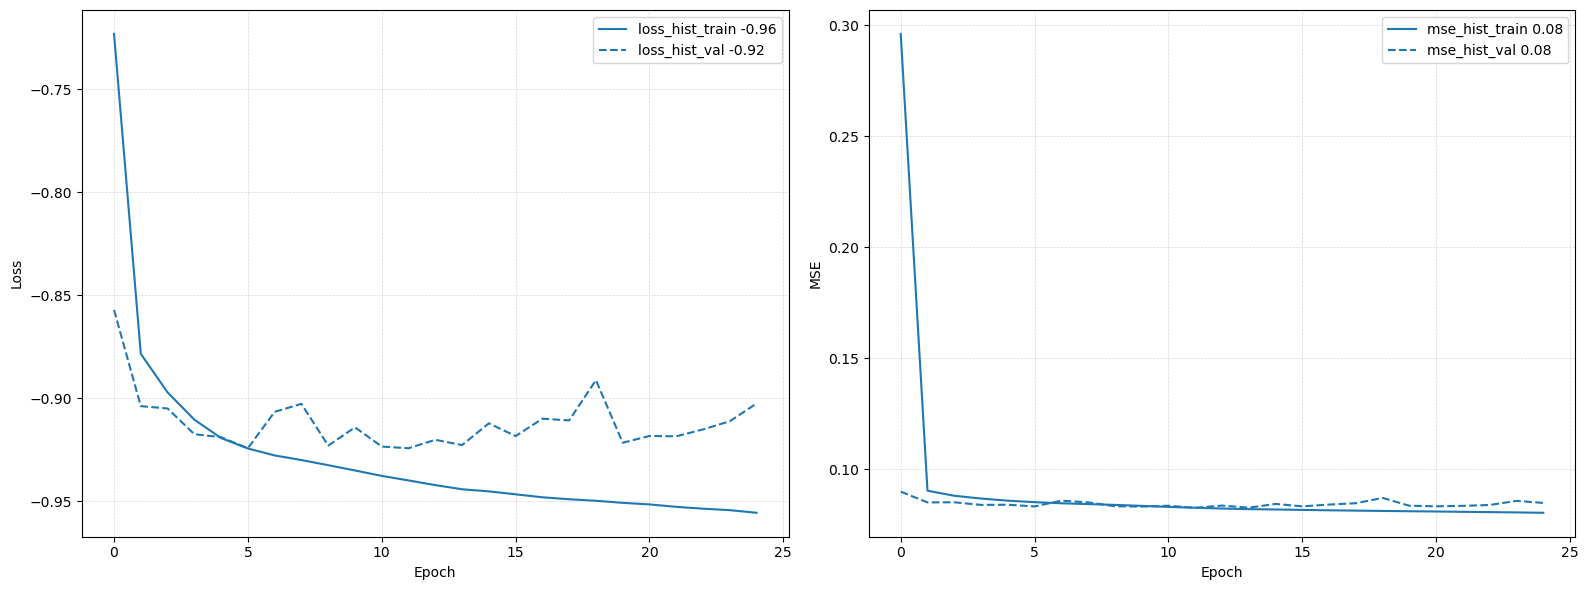

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

mlt.plotting.plot_metrics(history=metrics.to_dict("list"), metric_keys=["loss_hist"], ax=ax1, y_label="Loss")

mlt.plotting.plot_metrics(history=metrics.to_dict("list"), metric_keys=["mse_hist"], ax=ax2, y_label="MSE")

fig.tight_layout()

## Model Bias & Residual Standard Deviation

In [9]:
model_bias, res_std = res_df.mean(axis=0), res_df.std(axis=0)
emp_model_bias, emp_res_std = emp_res_red.mean(axis=0), emp_res_red.std(axis=0)

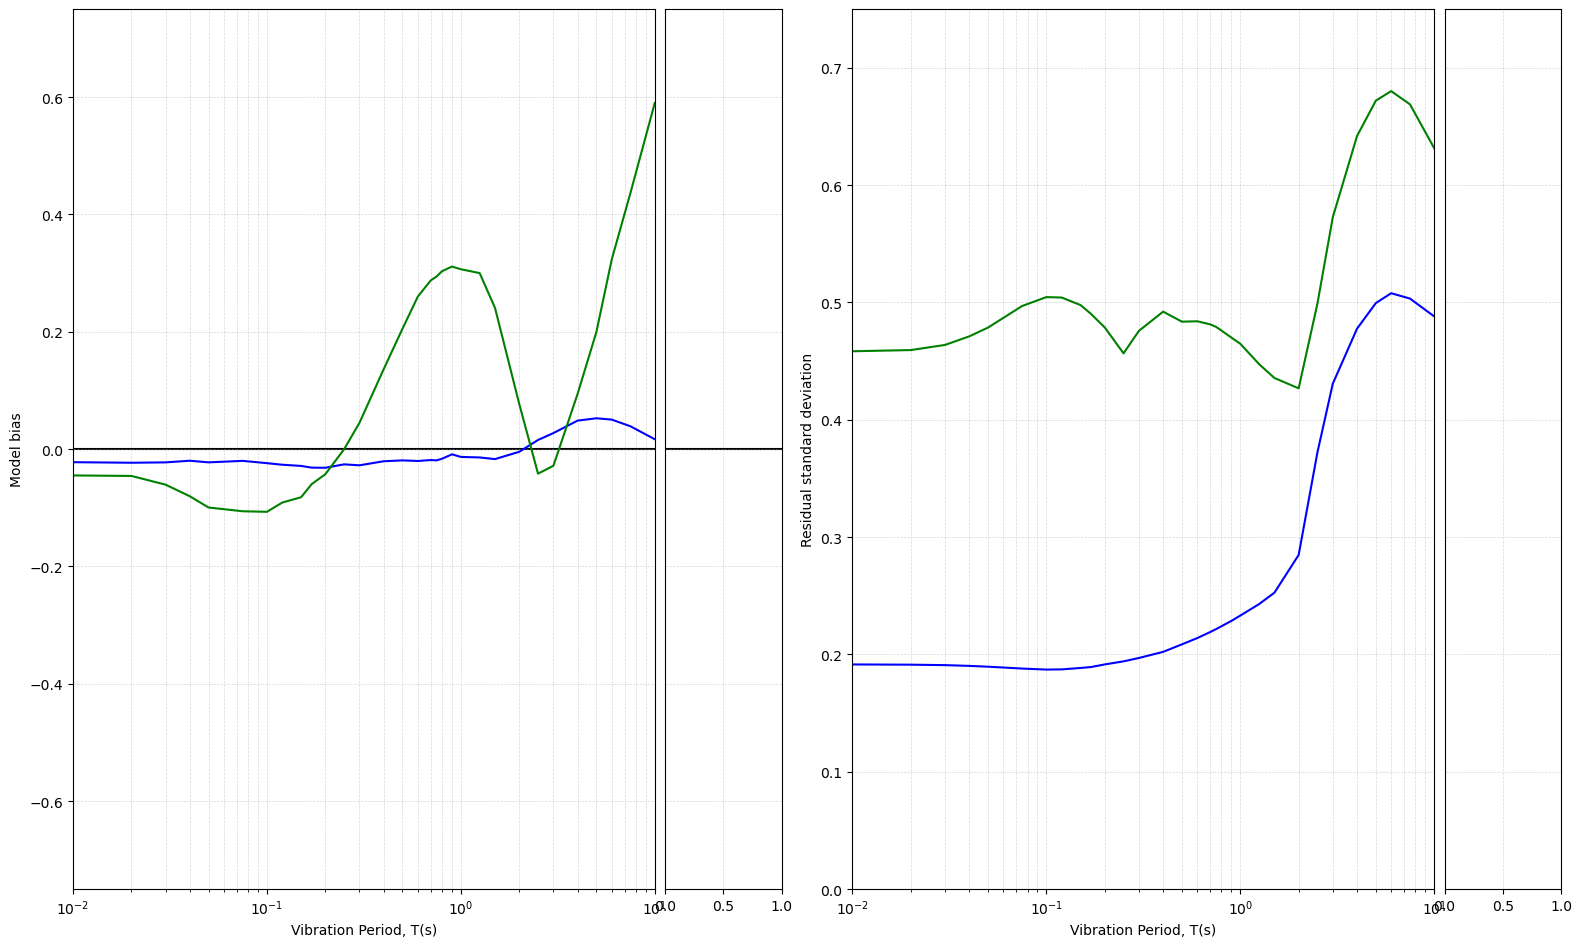

In [10]:
fig, ax1, ax2, ax3, ax4 = nng.plot_utils.get_bias_residual_fig(figsize=(16, 10), bias_y_axis_limits=(-0.75, 0.75), std_y_axis_limits=(0.0, 0.75))

ax1.plot(nng.constants.PSA_PERIODS, model_bias[nng.constants.PSA_KEYS].values, c="b")
ax1.plot(nng.constants.PSA_PERIODS, emp_model_bias[nng.constants.PSA_KEYS].values, c="g")

if run_config.im_set == "all":
    ax2.scatter(nng.constants.NON_PSA_IMS, model_bias[nng.constants.NON_PSA_IMS].values, c="b")

ax3.plot(nng.constants.PSA_PERIODS, res_std[nng.constants.PSA_KEYS].values, c="b")
ax3.plot(nng.constants.PSA_PERIODS, emp_res_std[nng.constants.PSA_KEYS].values, c="g")

if run_config.im_set == "all":
    ax4.scatter(nng.constants.NON_PSA_IMS, res_std[nng.constants.NON_PSA_IMS].values, c="b")

## Model Trends

### Magnitude

In [11]:
# Get magnitude predictions
input_df = nng.nn_gmm_predict.get_mag_input_df(
    mag_values = np.linspace(5.25, 8.25, 250),
    run_config=run_config,
    vs30=250,
    z1p0=0.25,
    z2p5= 5.0,
    tect_type=str(oqw.constants.TectType.ACTIVE_SHALLOW),
    rake=-90,
    dip=45,
    dtop=0,
    dbottom=10,
    rrup=50,
    rjb=50,
    rx=40,
    hypo_depth=9,
)

pred_df = nng.nn_gmm_predict.run_predictions(result_dir, input_df, device=device)

emp_pred_df = nng.emp_gmm.get_gmm_predictions(input_df, nng.constants.GMM_MAPPING)

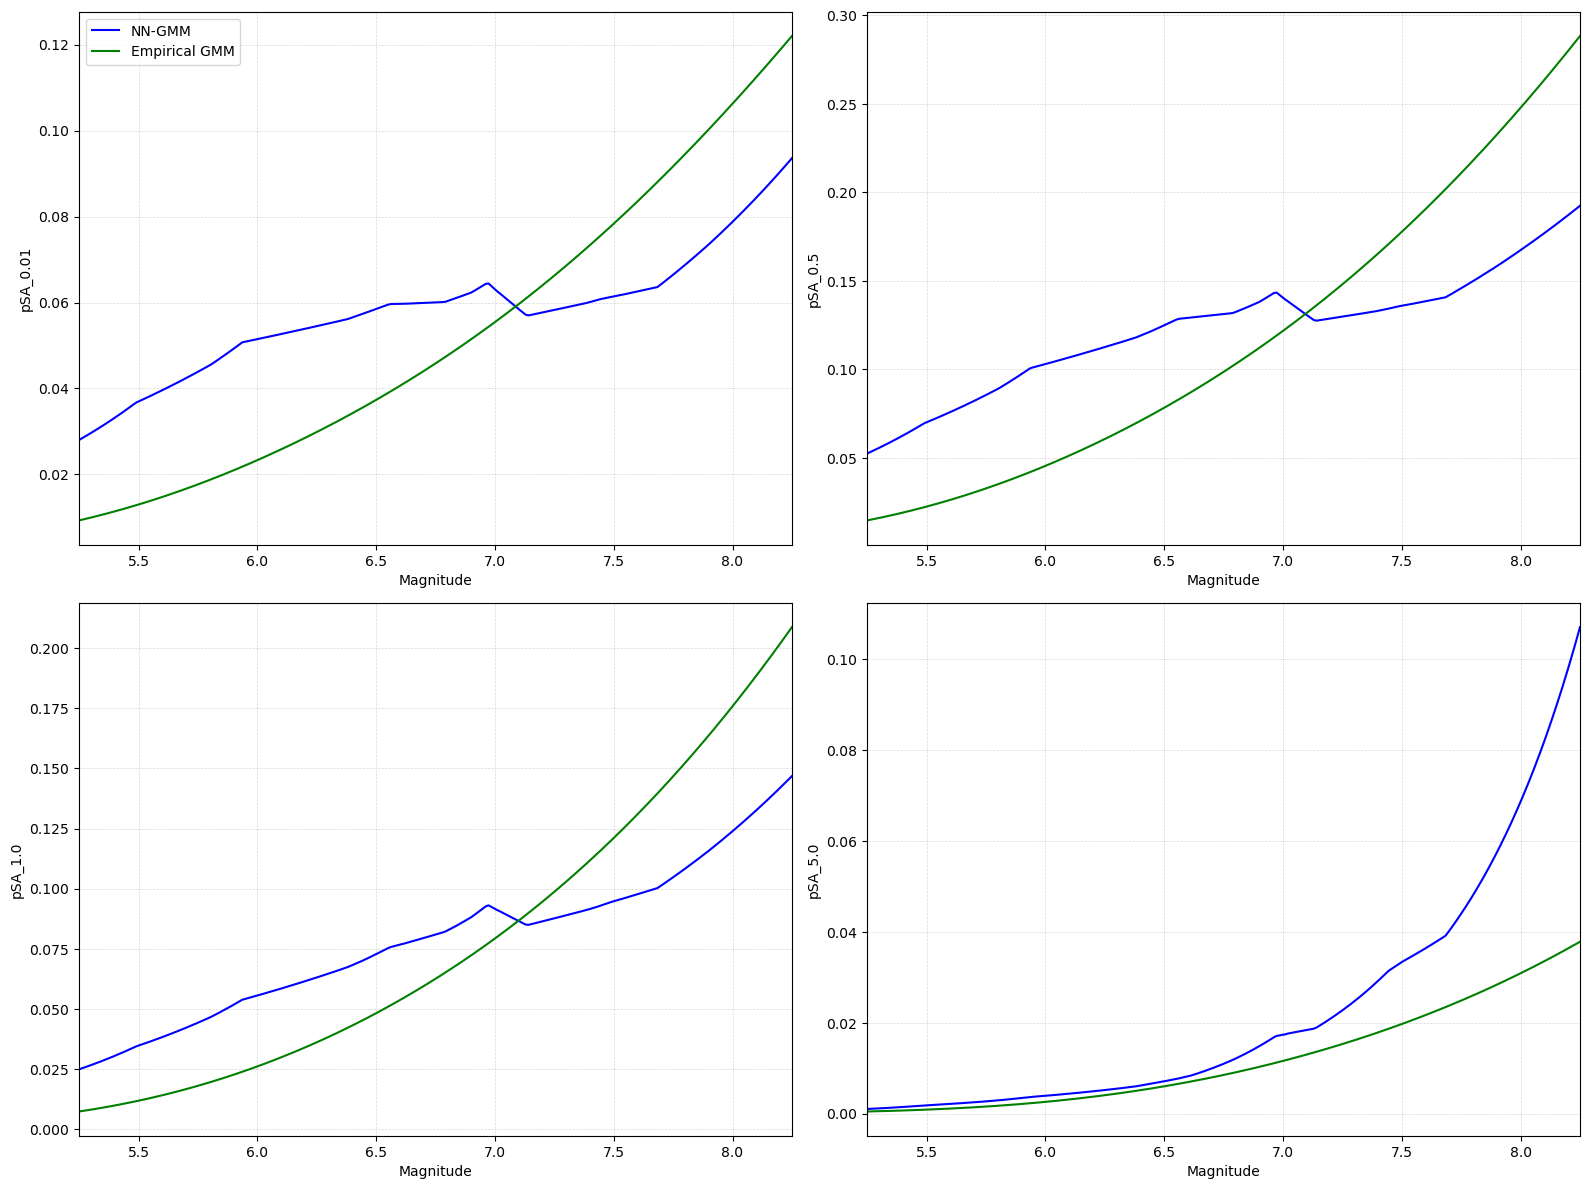

In [13]:
plot_ims = ["pSA_0.01", "pSA_0.5", "pSA_1.0", "pSA_5.0"]
fig, axs = mlt.plotting.get_fig_axes(4, 2, 2, ind_figsize=(8, 6))

for i, (ax, im) in enumerate(zip(axs, plot_ims)):
    ax.plot(pred_df["magnitude"], np.exp(pred_df[f"{im}_pred"]), c="b", label="NN-GMM")
    ax.plot(pred_df["magnitude"], np.exp(emp_pred_df[f"{im}_mean"]), c="g", label="Empirical GMM")

    ax.set_xlim(5.25, 8.25)
    ax.set_ylabel(im)
    ax.set_xlabel("Magnitude")
    ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

    if i == 0:
        ax.legend()


fig.tight_layout()